In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv('Churn.csv')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [59]:
df.duplicated().sum()

0

In [17]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [19]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

## Incorrect data types:
TotalCharges : object

In [22]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors = 'coerce')

In [24]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [65]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

TotalCharges contained blank values for customers with zero tenure. Since these customers had not accumulated any charges yet, the missing values were replaced with 0.

In [102]:
df['TotalCharges'].isna().sum()

0

In [67]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [69]:
n_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('SeniorCitizen')

print("Numerical Columns:", n_cols)

Numerical Columns: Index(['tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')


In [71]:
c_cols = list(df.select_dtypes(include='object').columns.drop(['Churn','customerID']))
c_cols.append('SeniorCitizen')

print("Categorical Columns:", c_cols)

Categorical Columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'SeniorCitizen']


# Univariate Analysis

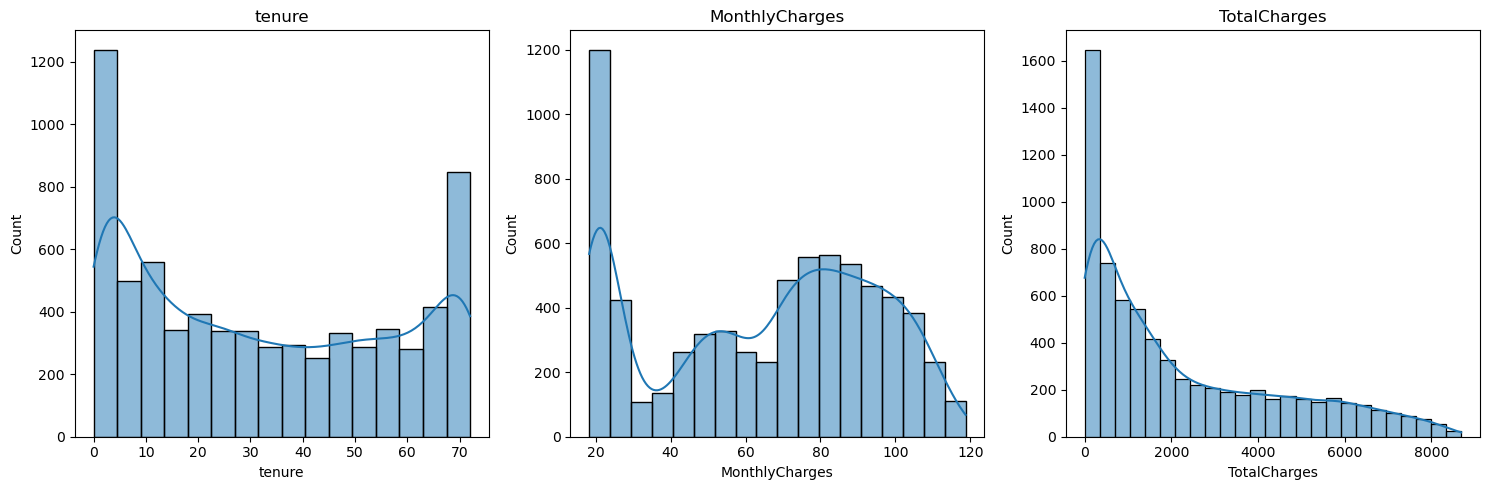

In [74]:
plt.figure(figsize=(15,5))

for i, col in enumerate(n_cols):
    plt.subplot(1, len(n_cols), i+1)   
    sns.histplot(data=df, x=col, kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

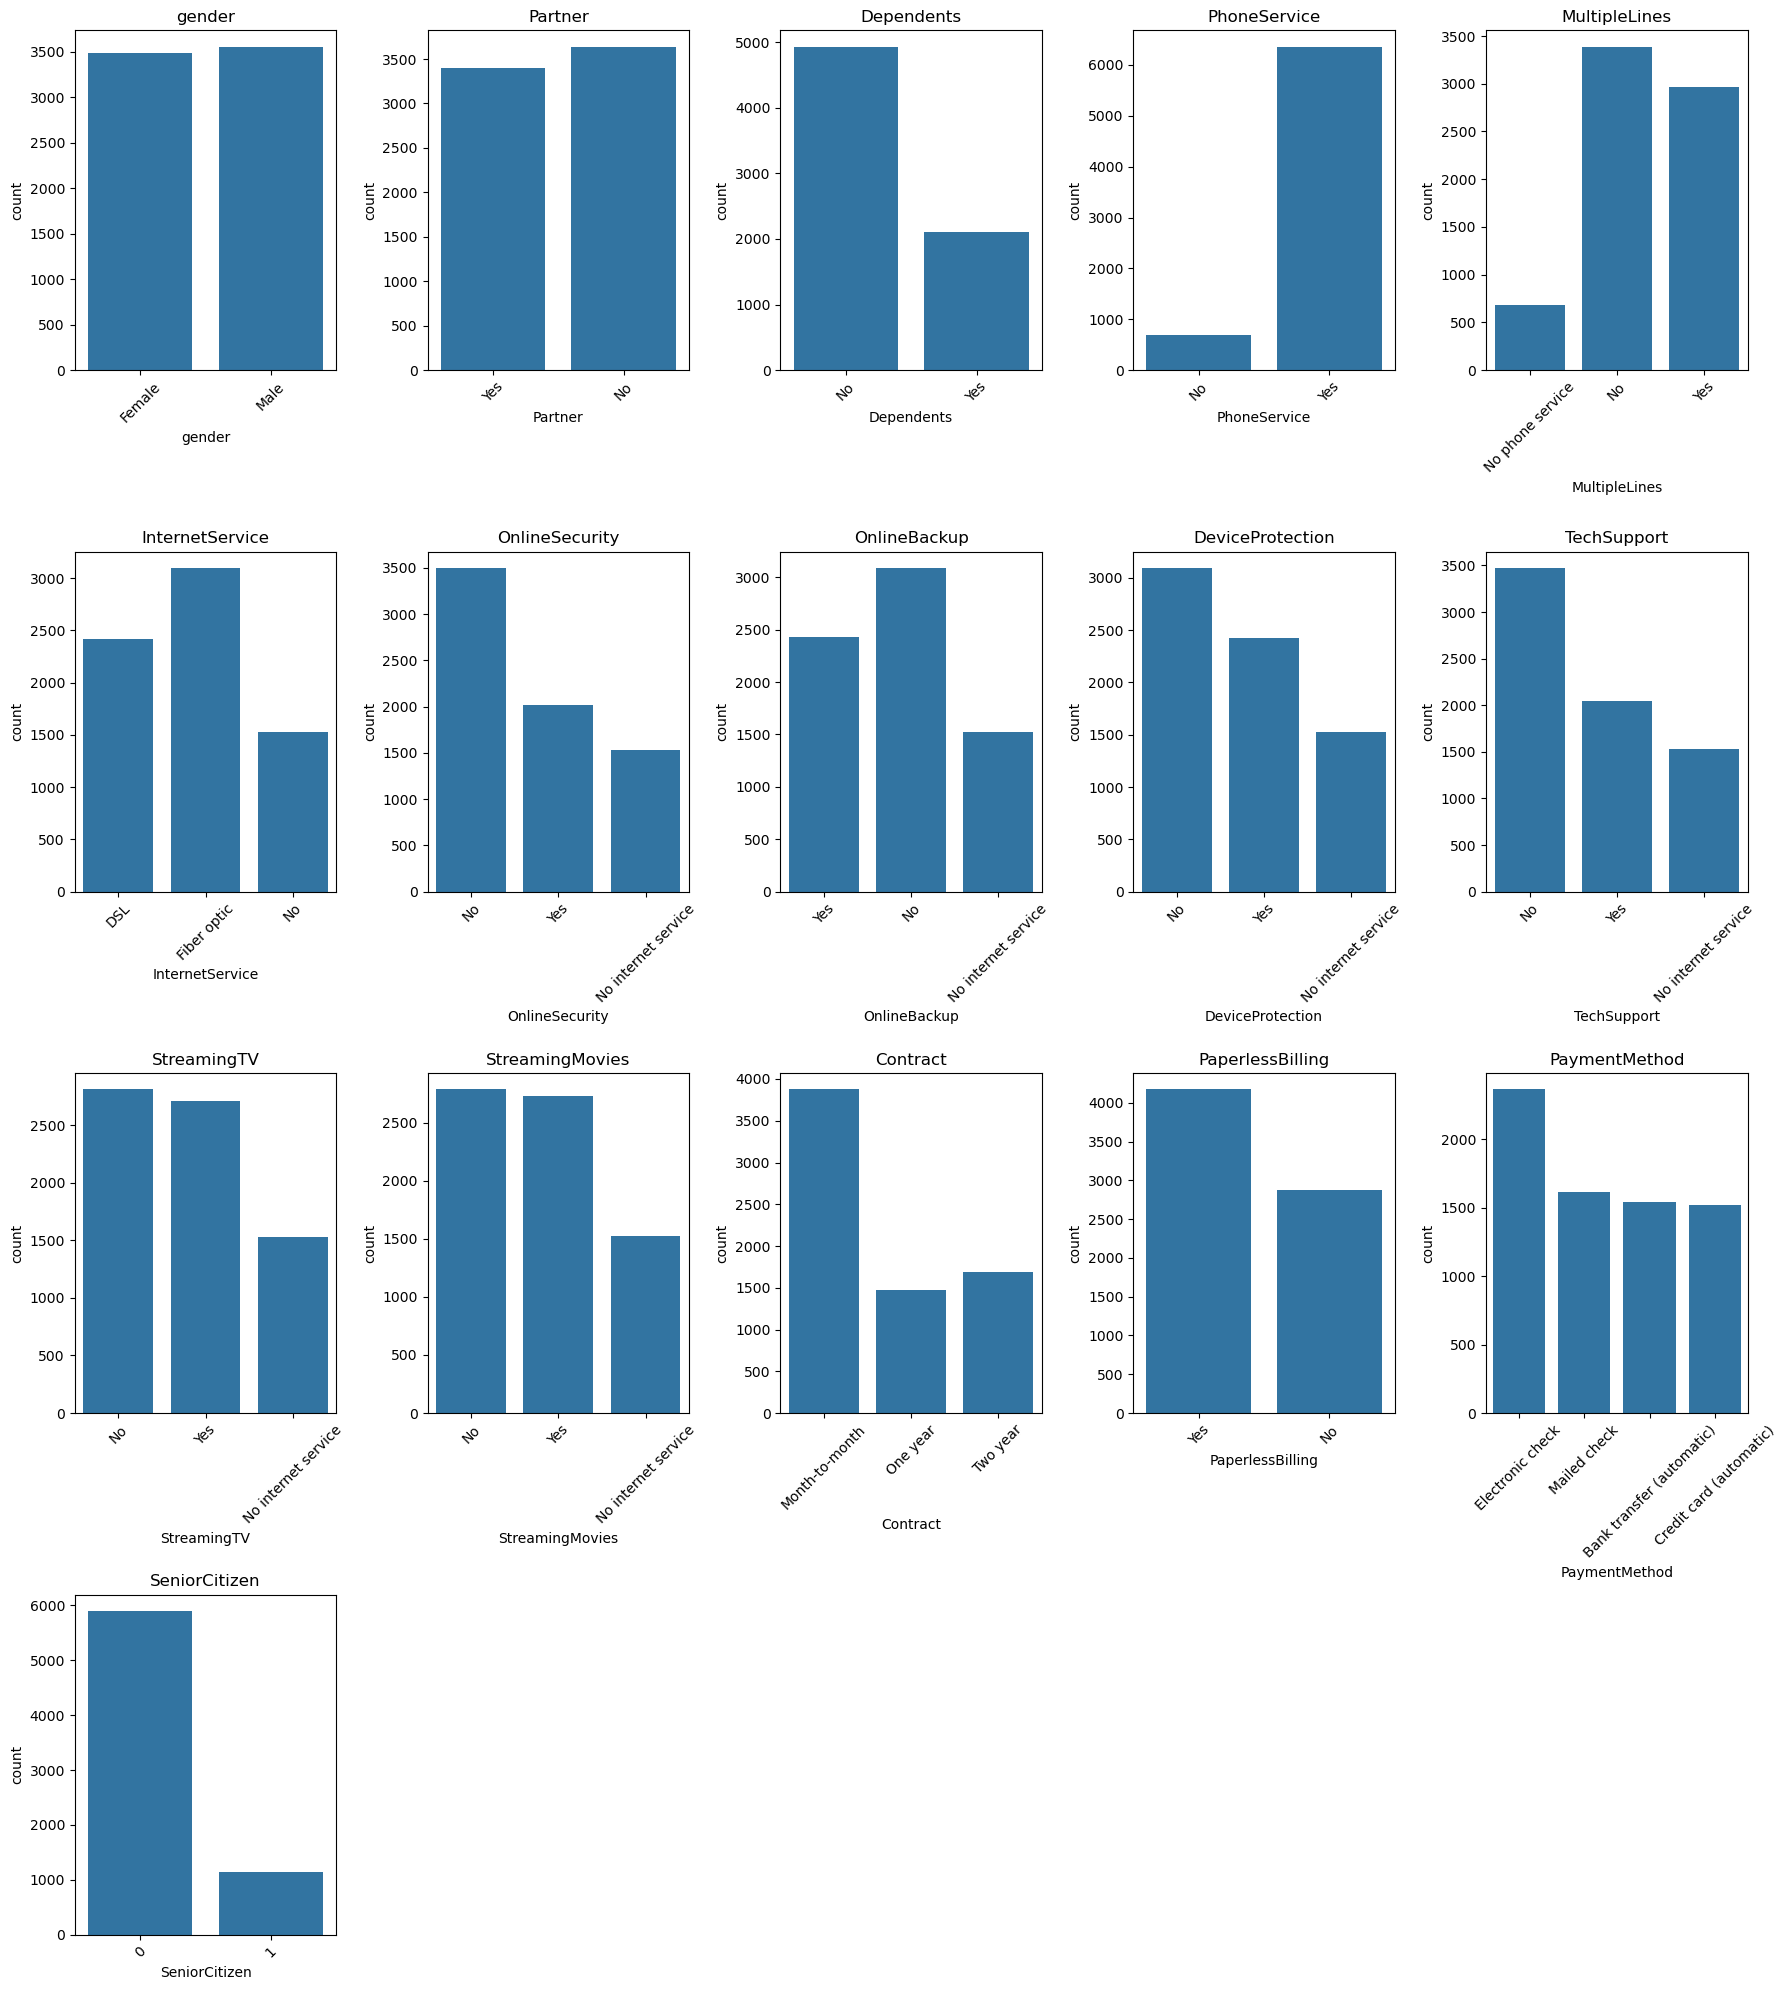

In [75]:
plt.figure(figsize=(18,20))
for i, col in enumerate(c_cols):
    plt.subplot(4,5,i+1)
    sns.countplot(x=col,data = df)
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

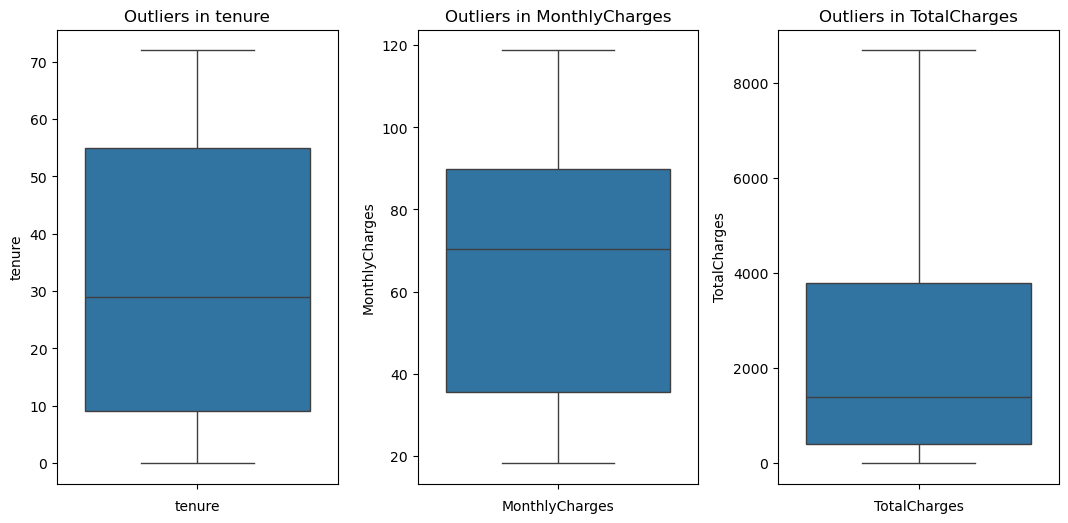

In [77]:
plt.figure(figsize=(18,20))
for i, col in enumerate(n_cols):
    plt.subplot(4,5,i+1)
    sns.boxplot(df[col])
    plt.title(f"Outliers in {col}")
    plt.xlabel(col)

plt.tight_layout()
plt.show()

# Univariate analysis:

## A.Histograms-

### 1.tenure - 

The data has wide spread and it has a bimodal distrbution (u-shaped).
It has two peaks near 0 and 72 leading to fact that either we have very new customers or long term customers.

### 2.MonthlyCharges -
MonthlyCharges shows a somewhat multimodal distribution, with concentrations around lower and higher charge ranges. This may reflect differences in subscribed services and plans.

### 3.TotalCharges -

TotalCharges are strongly right-skewed, with most customers having relatively low accumulated charges and a smaller number of customers having very high total charges. This likely reflects that many customers are relatively new, while fewer customers have remained with the company long enough to accumulate large total charges.

## B.Countplots-

### 1.SeniorCitizen-

Around 1,000 out of 7,000 customers are senior citizens, while the majority are non-senior citizens. This indicates that the customer base is primarily composed of non-senior users.


### 2.Partner

**Observations**
- The number of customers with a **partner and without a partner is almost balanced**.
- Slightly more customers appear to **not have a partner**.

**Insight**
- Relationship status is **fairly evenly distributed**, meaning it may or may not have a strong effect on churn and should be analyzed further with churn comparison.


### 3.Dependents

**Observations**
- Most customers **do not have dependents**.
- Customers with dependents form a **smaller portion of the dataset**.

**Insight**
- Customers without dependents might represent **younger or single users**, which could influence service usage patterns.



### 4.Contract

**Observations**
- **Month-to-month contracts dominate the dataset**.
- One-year and two-year contracts are significantly fewer.

**Insight**
- Customers with **short-term contracts may have a higher chance of churn** because they are not locked into long-term commitments.


### 5.OnlineBackup

**Observations**
- Many customers **do not use online backup services**.
- A moderate number of customers **use online backup**.
- Some customers show **"No Internet Service"**, meaning the service is unavailable to them.

**Insight**
- Additional services like backup are **not widely adopted by all users**, indicating potential upselling opportunities.



### 6.OnlineSecurity

**Observations**
- A large portion of customers **do not have online security services**.
- Fewer customers have enabled this service.

**Insight**
- Security services have **lower adoption**, which might influence customer retention and perceived service value.



### 7.PaymentMethod

**Observations**
- **Electronic check is the most common payment method**.
- Other payment methods such as **mailed check, bank transfer, and credit card** are used by fewer customers.

**Insight**
- Payment method preference may correlate with **customer demographics or churn behavior**.



### 8.InternetService

**Observations**
- **Fiber optic and DSL** are the primary internet services used.
- A smaller number of customers **do not have internet service**.

**Insight**
- Fiber optic users might have **different pricing and service experiences** compared to DSL users.



### 9.PhoneService

**Observations**
- The majority of customers **have phone service**.
- Only a small portion **do not use phone service**.

**Insight**
- Phone service is a **common base service** among customers.



### 10.DeviceProtection

**Observations**
- Many customers **do not use device protection**.
- Some customers have the service enabled.
- A portion of users have **no internet service**, making this feature irrelevant.

**Insight**
- Additional protective services are **not widely adopted**, similar to backup and security services.



### 11.TechSupport

**Observations**
- A large number of customers **do not use tech support services**.
- Fewer customers have active tech support.

**Insight**
- Low tech support usage may indicate **either good service stability or lack of awareness among customers**.

### 12.StreamingTV

**Observations**
- Customers are **fairly evenly distributed between using and not using streaming TV**.
- Some customers do not have internet service.

**Insight**
- Streaming services represent an **optional entertainment add-on rather than a core service**.



Most customers prefer short-term (month-to-month) contracts over long-term contracts. Phone and internet services act as the primary services, while additional services such as Online Backup, Device Protection, Tech Support, and Streaming are generally purchased by customers who already have internet service. Customers without internet service naturally do not subscribe to these internet-dependent add-on service

## C.Boxplots -

NO Significant Outliers are being detected.


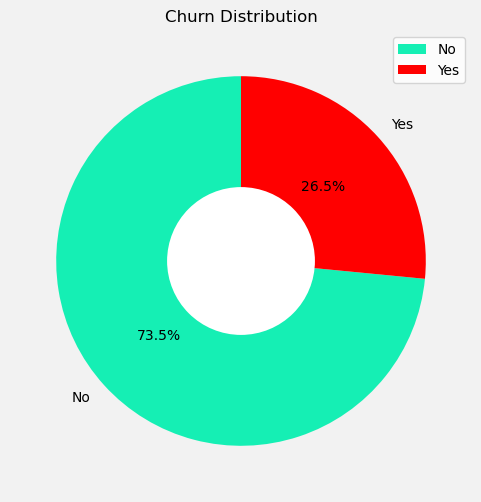

In [79]:
plt.figure(figsize=(6,6))
plt.gcf().set_facecolor('#f2f2f2')
plt.gca().set_facecolor('#faf7ff')

data = df['Churn'].value_counts()

colors = ['#15EFB4','#FF0000']

plt.pie(
    x=data,
    labels=data.index,        
    autopct='%1.1f%%',
    startangle=90,
    colors=colors
)

centre_circle = plt.Circle((0,0), 0.40, fc='white')
plt.gca().add_artist(centre_circle)

plt.legend(data.index, loc='upper right', bbox_to_anchor=(1,1))   

plt.grid(True)
plt.title('Churn Distribution')
plt.show()

# Target distribution - 

## In above pie chart :

The target variable is moderately imbalanced, with approximately 73.5% of customers not churning and 26.5% churning. This indicates that accuracy alone is not a sufficient evaluation metric, as a model predicting every customer as "No" would still achieve around 73.5% accuracy. Therefore, metrics such as Precision, Recall, F1-score, ROC-AUC, and the Confusion Matrix should also be used to evaluate model performance.

# Bivariate analysis

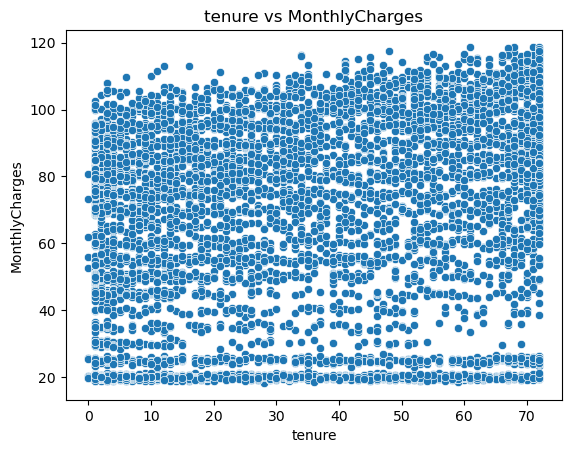

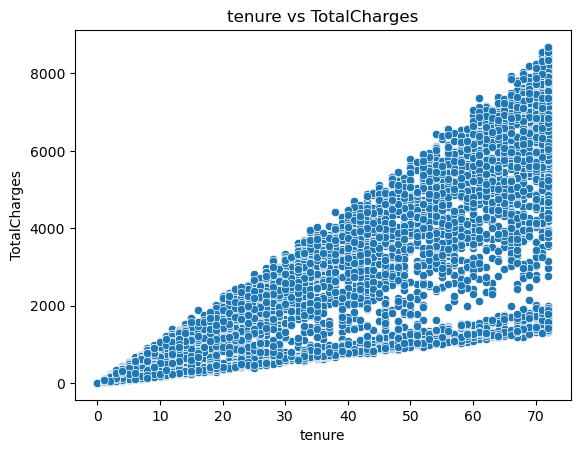

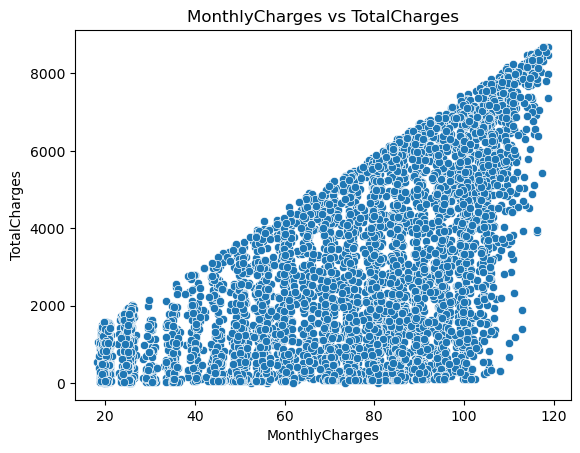

In [82]:
for i in range(len(n_cols)):
    for j in range(i+1,len(n_cols)):
        X=n_cols[i]
        Y=n_cols[j]
        
        sns.scatterplot(x=X,y=Y,data=df)
        plt.title(f"{X} vs {Y}")
        plt.show()

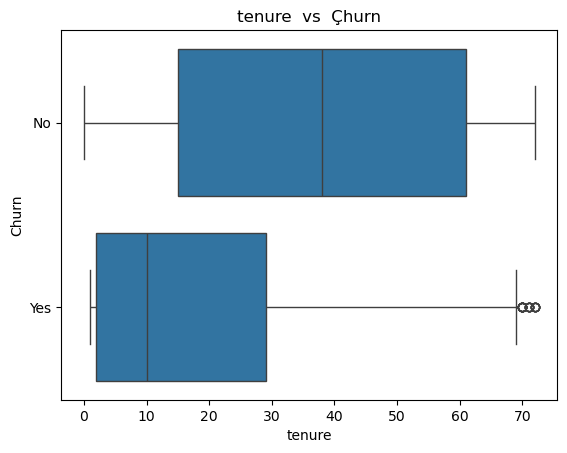

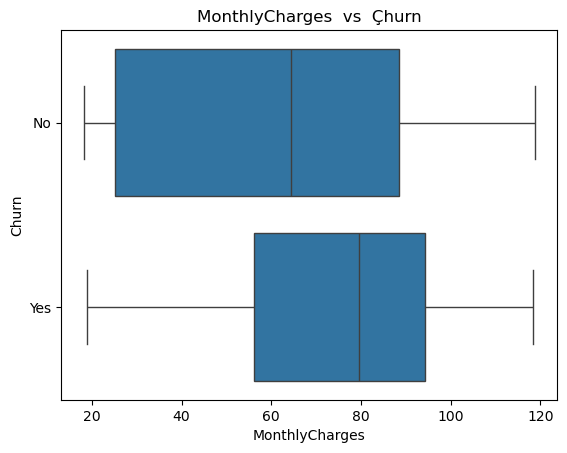

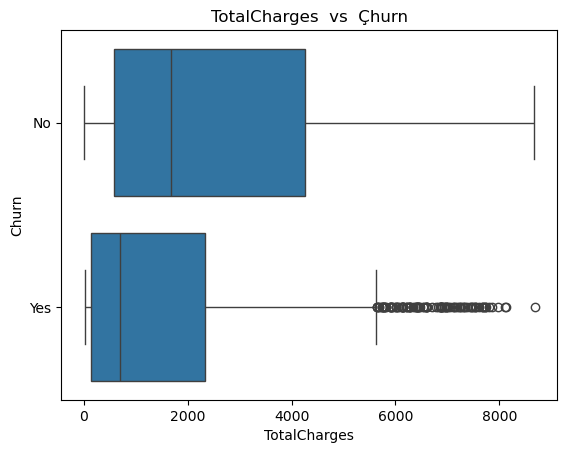

In [83]:
for col in n_cols:
    sns.boxplot(x=col,y='Churn',data=df)
    plt.title(f"{col}  vs  {'Çhurn'}")
    plt.show()

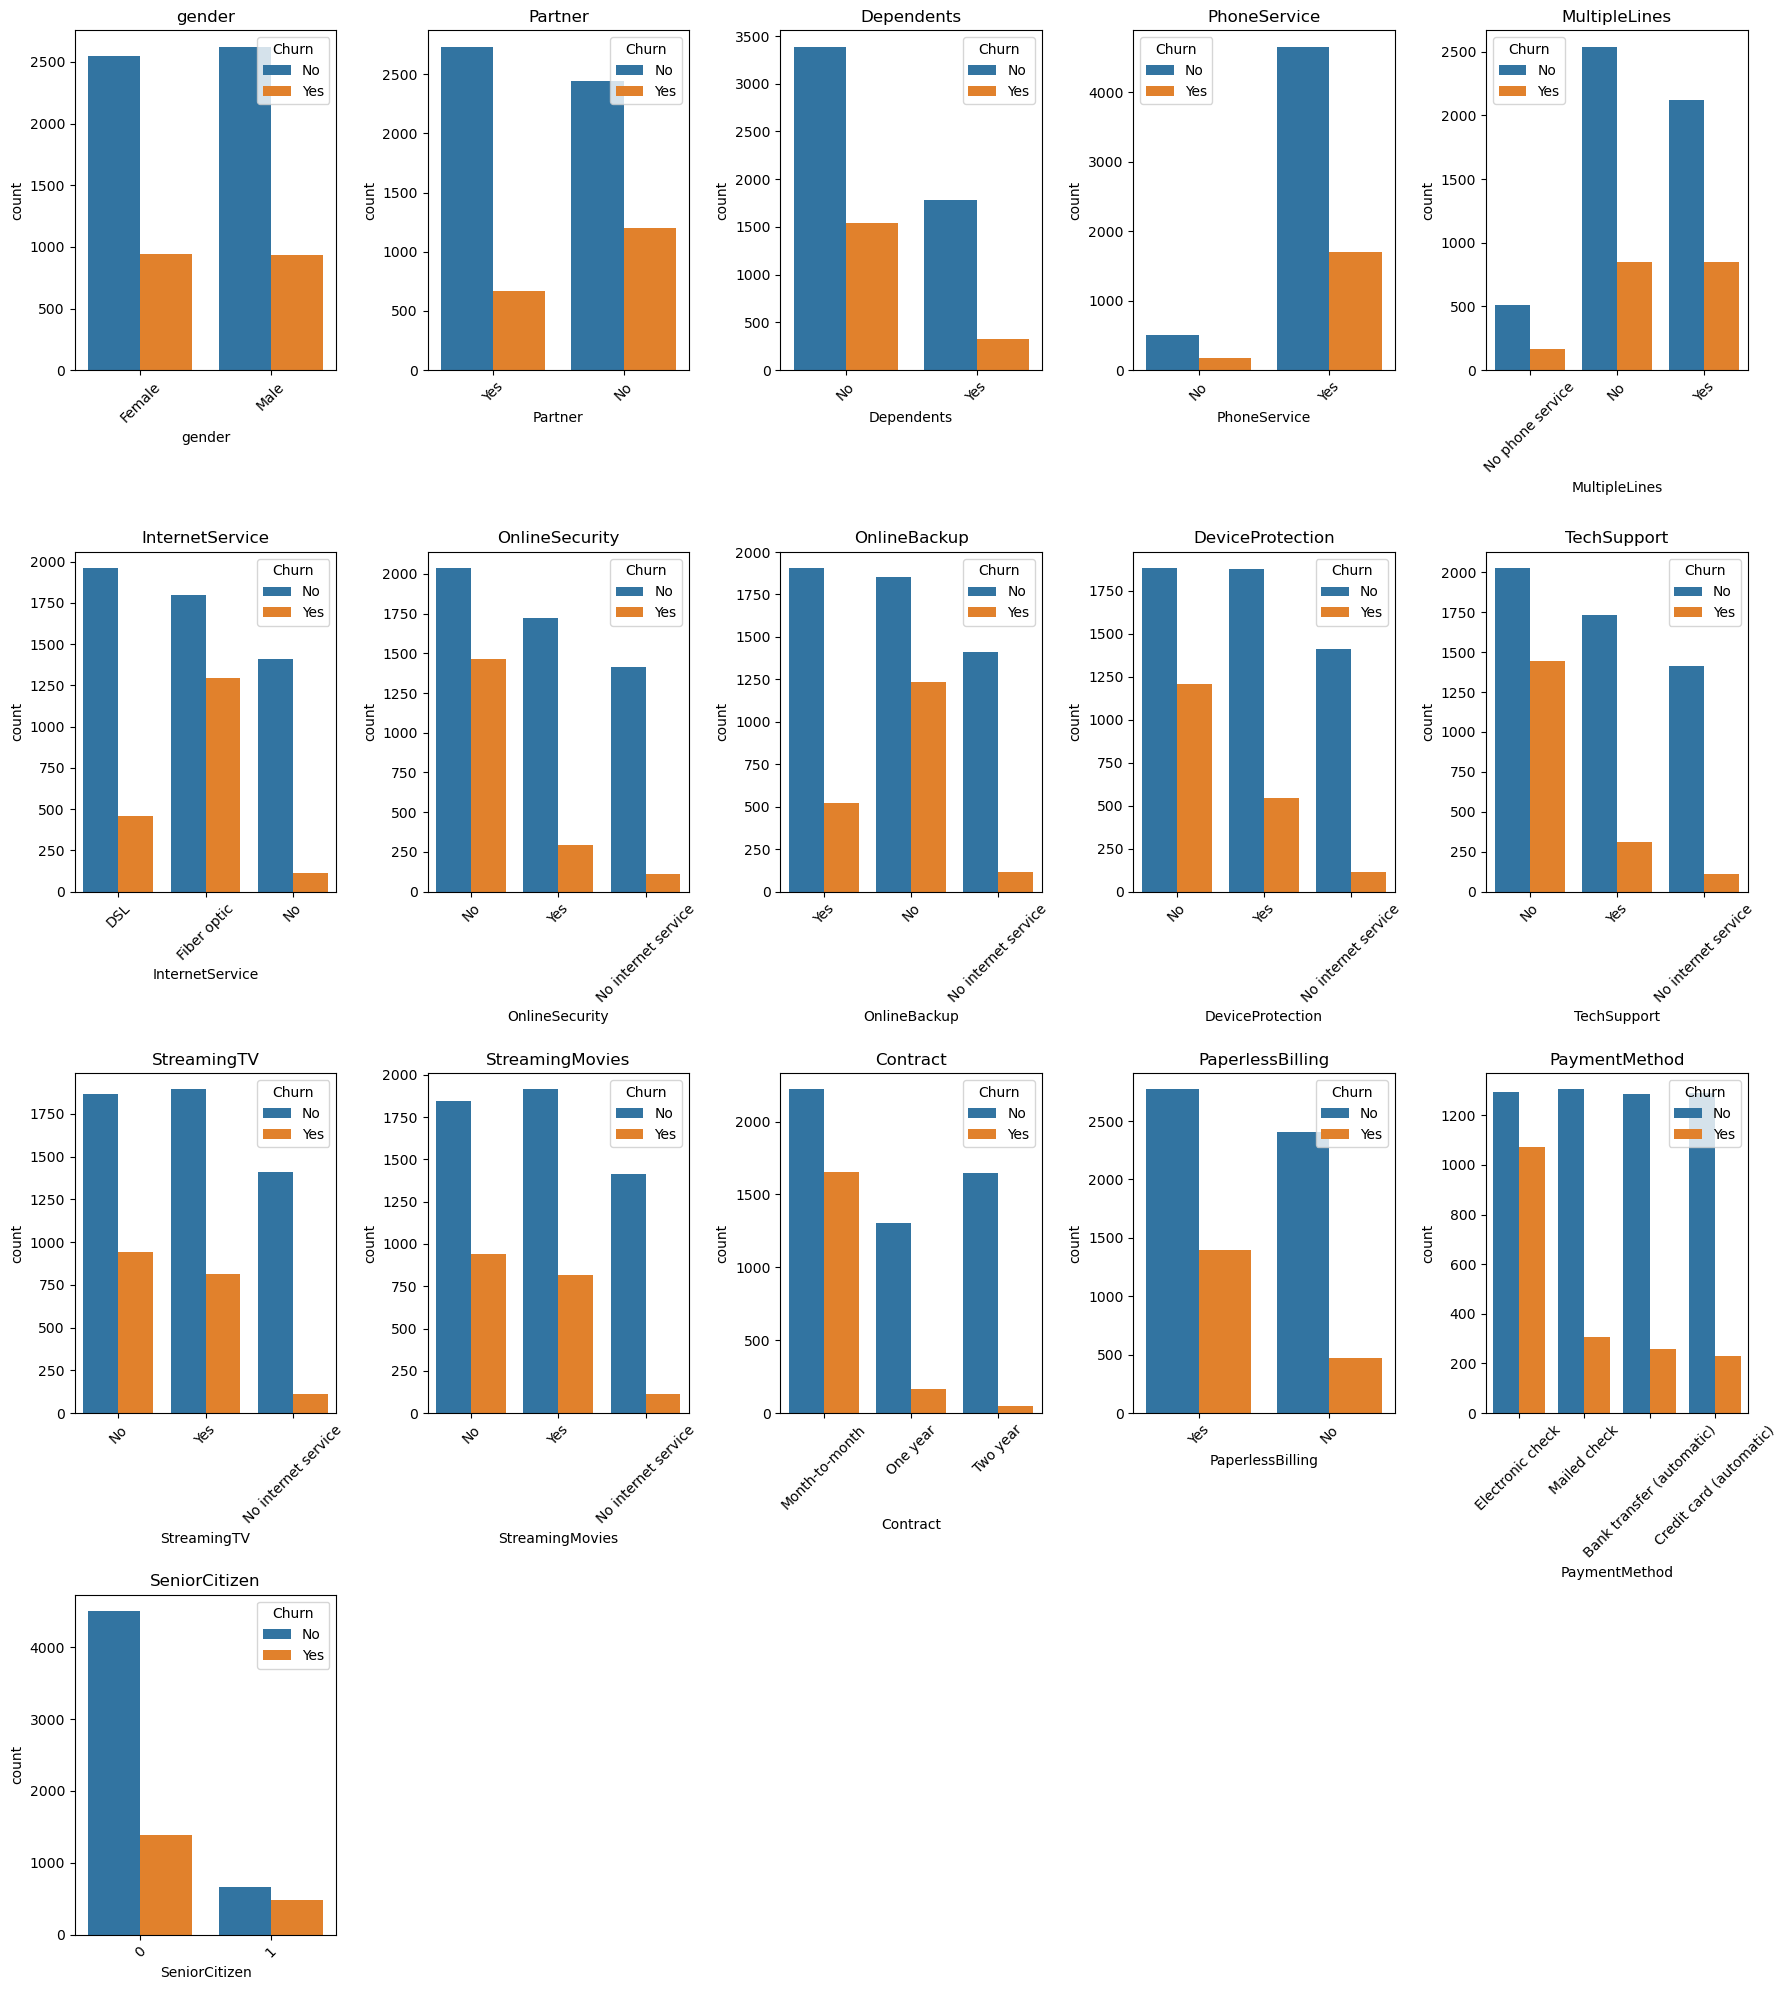

In [84]:
plt.figure(figsize=(18,20))
for i, col in enumerate(c_cols):
    plt.subplot(4,5,i+1)
    sns.countplot(x=col, hue='Churn', data=df)
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Bivariate Analysis

## A. Scatter Plots

### 1. Tenure vs MonthlyCharges

The scatter plot shows a weak positive relationship between tenure and MonthlyCharges. Customers with a longer tenure do not necessarily have higher monthly charges, indicating that tenure has only a slight influence on MonthlyCharges.

### 2. Tenure vs TotalCharges

The scatter plot shows a strong positive relationship between tenure and TotalCharges. As customer tenure increases, TotalCharges also increase because customers who stay longer accumulate charges over time.

### 3. MonthlyCharges vs TotalCharges

The scatter plot shows a strong positive relationship between MonthlyCharges and TotalCharges. Customers with higher MonthlyCharges generally have higher TotalCharges, although TotalCharges are also influenced by customer tenure.

## B.Boxplots -  Numerical Features vs Target (Churn)

### 1. Tenure vs Churn

The median tenure of customers who did not churn is higher than that of customers who churned. This indicates that customers with longer tenure are less likely to churn.

### 2. MonthlyCharges vs Churn

Customers who churn have a higher median MonthlyCharges than customers who do not churn. This suggests that higher monthly charges may be associated with increased churn.

### 3. TotalCharges vs Churn

Customers who did not churn have a higher median TotalCharges than customers who churned. This is because long-term customers accumulate higher total charges over time.
A few outliers are observed in both churn categories, but they appear to be valid observations and are therefore retained.

## C.Countplots - Categorical Features vs Target (Churn)

### 1. Gender vs Churn

Both male and female customers have a similar churn distribution, indicating that gender has little influence on customer churn.

### 2. SeniorCitizen vs Churn

Senior citizens have a higher churn rate compared to non-senior customers.

### 3. Partner vs Churn

Customers without a partner are more likely to churn than customers with a partner.

### 4. Dependents vs Churn

Customers without dependents have a higher churn rate than customers with dependents.

### 5. PhoneService vs Churn

Phone service does not show a significant difference in churn rate.

### 6. MultipleLines vs Churn

Customers with multiple lines have a slightly higher churn rate than customers without multiple lines.

### 7. InternetService vs Churn

Customers using Fiber optic internet have the highest churn rate, while customers with no internet service have the lowest.

### 8. OnlineSecurity vs Churn

Customers without online security are more likely to churn.

### 9. OnlineBackup vs Churn

Customers without online backup show a higher churn rate.

### 10. DeviceProtection vs Churn

Customers without device protection are more likely to churn.

### 11. TechSupport vs Churn

Customers without tech support have a higher churn rate than customers with tech support.

### 12. StreamingTV vs Churn

Streaming TV service does not show a significant difference in churn.

### 13. StreamingMovies vs Churn

Streaming Movies service does not show a significant difference in churn.

### 14. Contract vs Churn

Customers with month-to-month contracts have the highest churn rate, whereas one-year and two-year contract customers are less likely to churn.

### 15. PaperlessBilling vs Churn

Customers using paperless billing have a higher churn rate.

### 16. PaymentMethod vs Churn

Customers using Electronic check have the highest churn rate among all payment methods.


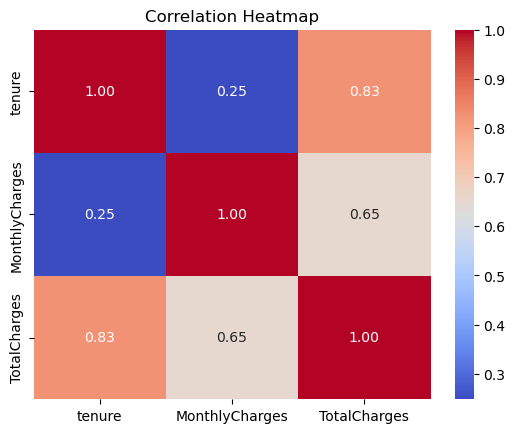

In [86]:
sns.heatmap(
    df[n_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Correlation Heatmap")
plt.show()

# Multivariate analysis 

## Correlation Heatmap

### Observations

- Tenure and TotalCharges have a strong positive correlation (0.83).
- MonthlyCharges and TotalCharges have a moderate positive correlation (0.65).
- Tenure and MonthlyCharges have a weak positive correlation (0.25).

### Insights

- Customers with longer tenure tend to accumulate higher TotalCharges.
- Higher MonthlyCharges contribute to higher TotalCharges, but tenure also plays an important role.
- The heatmap confirms the relationships observed in the scatterplots.

### Multicollinearity check: 
The correlation heatmap identified a strong positive correlation (0.83) between tenure and TotalCharges, suggesting possible multicollinearity. Since Logistic Regression can be sensitive to multicollinearity, this relationship will be investigated further before deciding whether either feature should be removed.

In [88]:
df.to_csv("clean_Churn.csv", index=False)